# 📓 Notebook 04 – ANN Model Training
## Lettuce Fresh Weight Prediction | ANN + PSO

**Mode: Local (VS Code)**

Pipeline:
1. Load dataset → Split 80/20 → MinMaxScaler
2. Training ANN (MLPRegressor) arsitektur 64-32-16
3. Evaluasi: MAE, RMSE, R², MAPE
4. Visualisasi: actual vs predicted, training curve, residual, feature importance
5. Simpan model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.edgecolor': '#0f3460', 'grid.color': '#0f3460', 'axes.grid': True,
})
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
BASE_DIR = r'D:/laragon/www/lettuce-weight-prediction'

df = pd.read_csv(f'{BASE_DIR}/data/dataset.csv')

FEATURE_COLUMNS = [
    'leaf_area', 'perimeter', 'aspect_ratio', 'extent', 'equivalent_diameter',
    'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V', 'std_G',
    'contrast', 'energy', 'homogeneity', 'correlation', 'entropy'
]

X = df[FEATURE_COLUMNS].values
y = df['weight_gram'].values

print(f'✅ Dataset: {X.shape[0]} sampel | {X.shape[1]} fitur')
print(f'📈 Berat  : {y.min():.1f}g – {y.max():.1f}g | rata-rata: {y.mean():.2f}g')

✅ Dataset: 200 sampel | 17 fitur
📈 Berat  : 18.0g – 45.0g | rata-rata: 31.97g


## A. Data Preparation – Split & Normalisasi

In [3]:
# Train/Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# MinMaxScaler – fit hanya pada training data
scaler    = MinMaxScaler(feature_range=(0, 1))
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'📊 Training  : {len(X_train)} sampel (80%)')
print(f'📊 Testing   : {len(X_test)} sampel (20%)')
print(f'✅ Scaling   : [{X_train_s.min():.3f}, {X_train_s.max():.3f}]')

# Simpan scaler
os.makedirs(f'{BASE_DIR}/output/models', exist_ok=True)
joblib.dump(scaler, f'{BASE_DIR}/output/models/scaler.pkl')
print(f'✅ Scaler disimpan → output/models/scaler.pkl')

📊 Training  : 160 sampel (80%)
📊 Testing   : 40 sampel (20%)
✅ Scaling   : [0.000, 1.000]
✅ Scaler disimpan → output/models/scaler.pkl


## B. Training ANN

In [4]:
print('🧠 ANN ARCHITECTURE')
print('  Input  : 17 neurons')
print('  Hidden1: 64 neurons + ReLU')
print('  Hidden2: 32 neurons + ReLU')
print('  Hidden3: 16 neurons + ReLU')
print('  Output : 1 neuron (berat gram)')
print()

ann = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-4,
    random_state=42,
    verbose=False
)

print('🔄 Training...')
ann.fit(X_train_s, y_train)

# FIX: best_loss_ bisa None di sklearn>=1.6 saat early_stopping=True
# Gunakan loss_curve_[-1] sebagai gantinya
final_loss = ann.loss_curve_[-1] if ann.loss_curve_ else None
best_loss  = ann.best_loss_ if ann.best_loss_ is not None else final_loss

print(f'✅ Training selesai!')
print(f'   Iterasi    : {ann.n_iter_}')
print(f'   Final loss : {final_loss:.6f}')
print(f'   Best loss  : {best_loss:.6f}' if best_loss is not None else '   Best loss : N/A')

🧠 ANN ARCHITECTURE
  Input  : 17 neurons
  Hidden1: 64 neurons + ReLU
  Hidden2: 32 neurons + ReLU
  Hidden3: 16 neurons + ReLU
  Output : 1 neuron (berat gram)

🔄 Training...
✅ Training selesai!
   Iterasi    : 500
   Final loss : 6.724006
   Best loss  : 6.724006


## C. Evaluasi Model

In [5]:
def calc_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    if label:
        print(f'\n📊 {label}')
        print(f'  MAE  : {mae:.4f} gram')
        print(f'  RMSE : {rmse:.4f} gram')
        print(f'  R²   : {r2:.4f}')
        print(f'  MAPE : {mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

y_train_pred = ann.predict(X_train_s)
y_test_pred  = ann.predict(X_test_s)

train_m = calc_metrics(y_train, y_train_pred, 'TRAINING SET')
test_m  = calc_metrics(y_test,  y_test_pred,  'TESTING SET')

gap = abs(train_m['RMSE'] - test_m['RMSE'])
print(f'\n🔍 Overfitting check – Gap RMSE: {gap:.4f}g → ', end='')
print('✅ OK' if gap < 5 else ('⚠️ Slight' if gap < 15 else '❌ Overfit'))


📊 TRAINING SET
  MAE  : 2.6921 gram
  RMSE : 3.5380 gram
  R²   : 0.6325
  MAPE : 8.78%

📊 TESTING SET
  MAE  : 2.7901 gram
  RMSE : 3.6239 gram
  R²   : 0.6350
  MAPE : 8.88%

🔍 Overfitting check – Gap RMSE: 0.0860g → ✅ OK


## D. Visualisasi

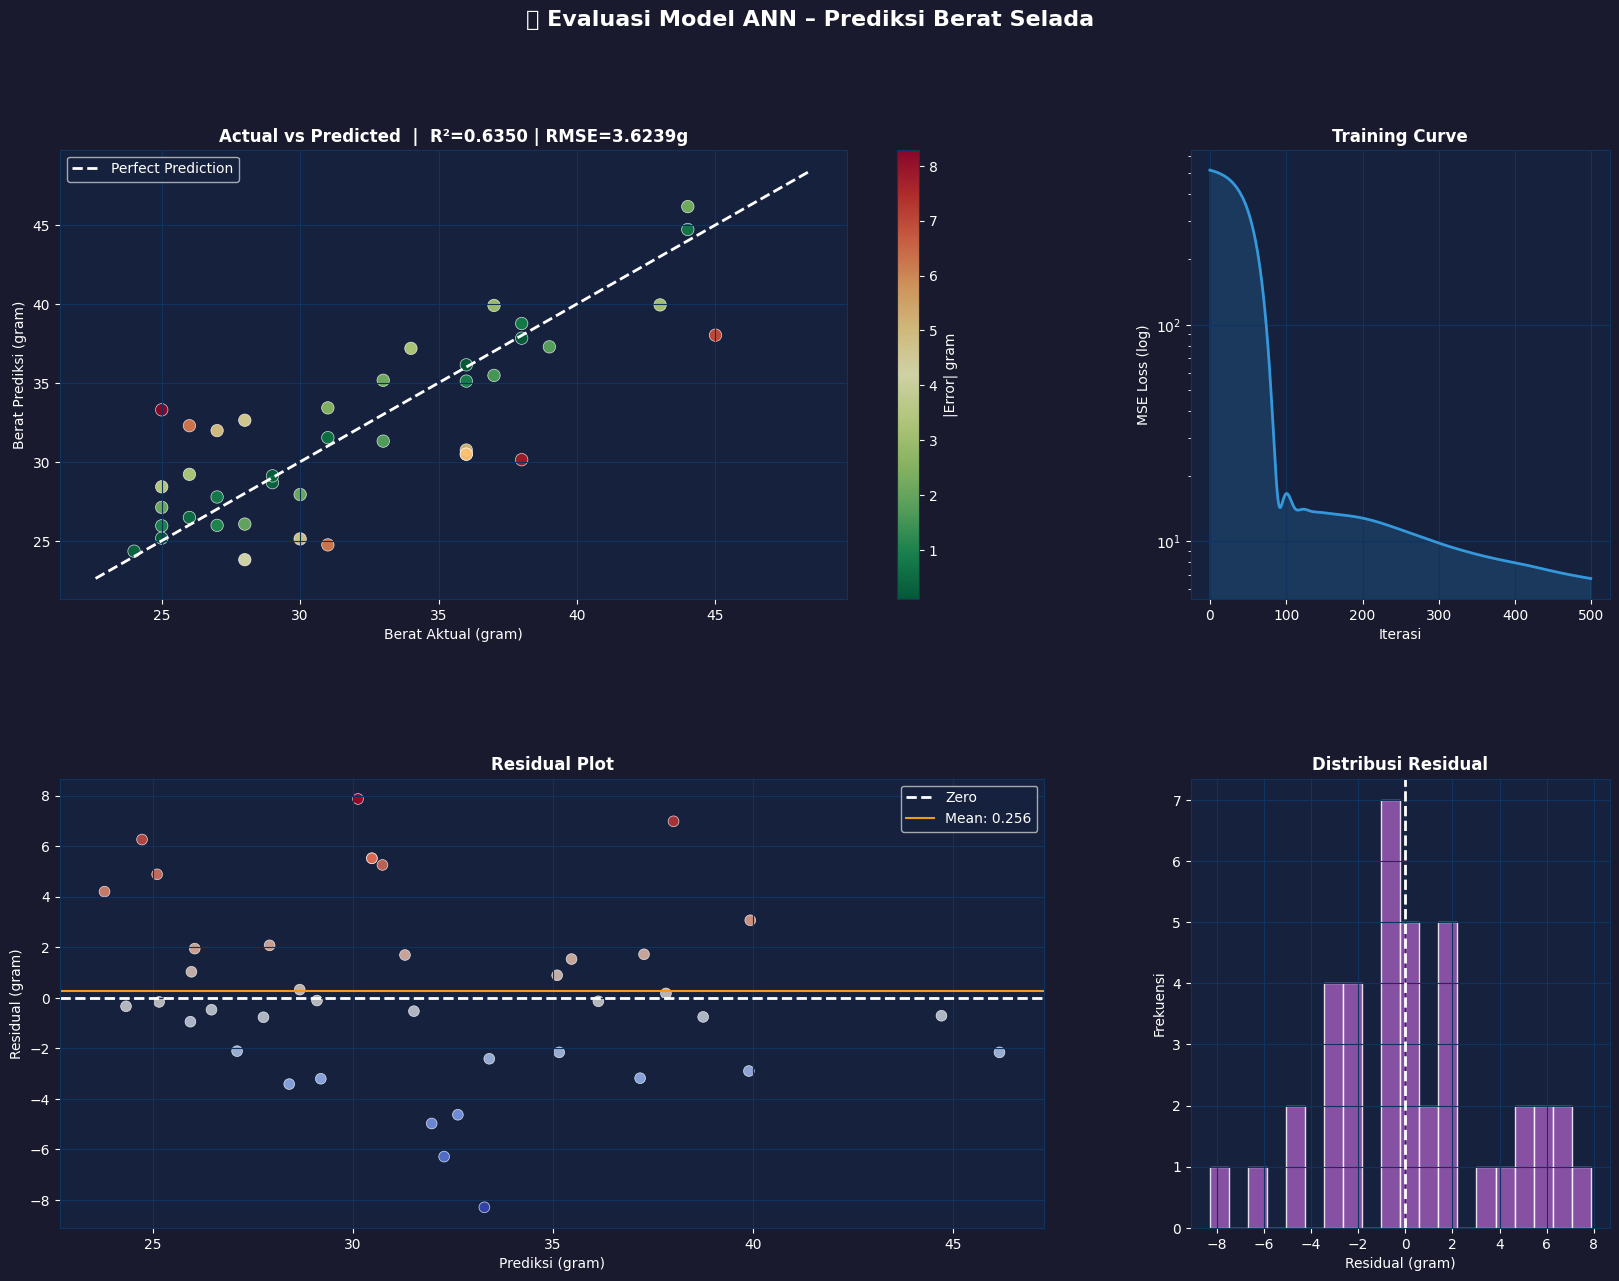

✅ Simpan → output/plots/actual_vs_predicted.png


In [6]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)
fig.suptitle('📊 Evaluasi Model ANN – Prediksi Berat Selada',
             fontsize=16, fontweight='bold', color='white')

# 1. Actual vs Predicted
ax1 = fig.add_subplot(gs[0, :2])
err = np.abs(y_test - y_test_pred)
sc  = ax1.scatter(y_test, y_test_pred, c=err, cmap='RdYlGn_r', s=80, alpha=0.8, edgecolors='white', lw=0.5)
plt.colorbar(sc, ax=ax1, label='|Error| gram')
lim = [min(y_test.min(), y_test_pred.min())*0.95, max(y_test.max(), y_test_pred.max())*1.05]
ax1.plot(lim, lim, 'w--', lw=2, label='Perfect Prediction')
ax1.set_title(f'Actual vs Predicted  |  R²={test_m["R2"]:.4f} | RMSE={test_m["RMSE"]:.4f}g', fontsize=12, fontweight='bold')
ax1.set_xlabel('Berat Aktual (gram)'); ax1.set_ylabel('Berat Prediksi (gram)')
ax1.legend()

# 2. Training Curve
ax2 = fig.add_subplot(gs[0, 2])
lc  = ann.loss_curve_
ax2.semilogy(lc, color='#3498DB', lw=2)
ax2.fill_between(range(len(lc)), lc, alpha=0.2, color='#3498DB')
ax2.set_title('Training Curve', fontsize=12, fontweight='bold')
ax2.set_xlabel('Iterasi'); ax2.set_ylabel('MSE Loss (log)')

# 3. Residual Plot
ax3   = fig.add_subplot(gs[1, :2])
resid = y_test - y_test_pred
ax3.scatter(y_test_pred, resid, c=resid, cmap='coolwarm', s=60, alpha=0.8, edgecolors='white', lw=0.5)
ax3.axhline(0, color='white', ls='--', lw=2, label='Zero')
ax3.axhline(resid.mean(), color='#F39C12', lw=1.5, label=f'Mean: {resid.mean():.3f}')
ax3.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax3.set_xlabel('Prediksi (gram)'); ax3.set_ylabel('Residual (gram)')
ax3.legend()

# 4. Residual Distribution
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(resid, bins=20, color='#9B59B6', edgecolor='white', alpha=0.85)
ax4.axvline(0, color='white', ls='--', lw=2)
ax4.set_title('Distribusi Residual', fontsize=12, fontweight='bold')
ax4.set_xlabel('Residual (gram)'); ax4.set_ylabel('Frekuensi')

plt.savefig(f'{BASE_DIR}/output/plots/actual_vs_predicted.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/actual_vs_predicted.png')

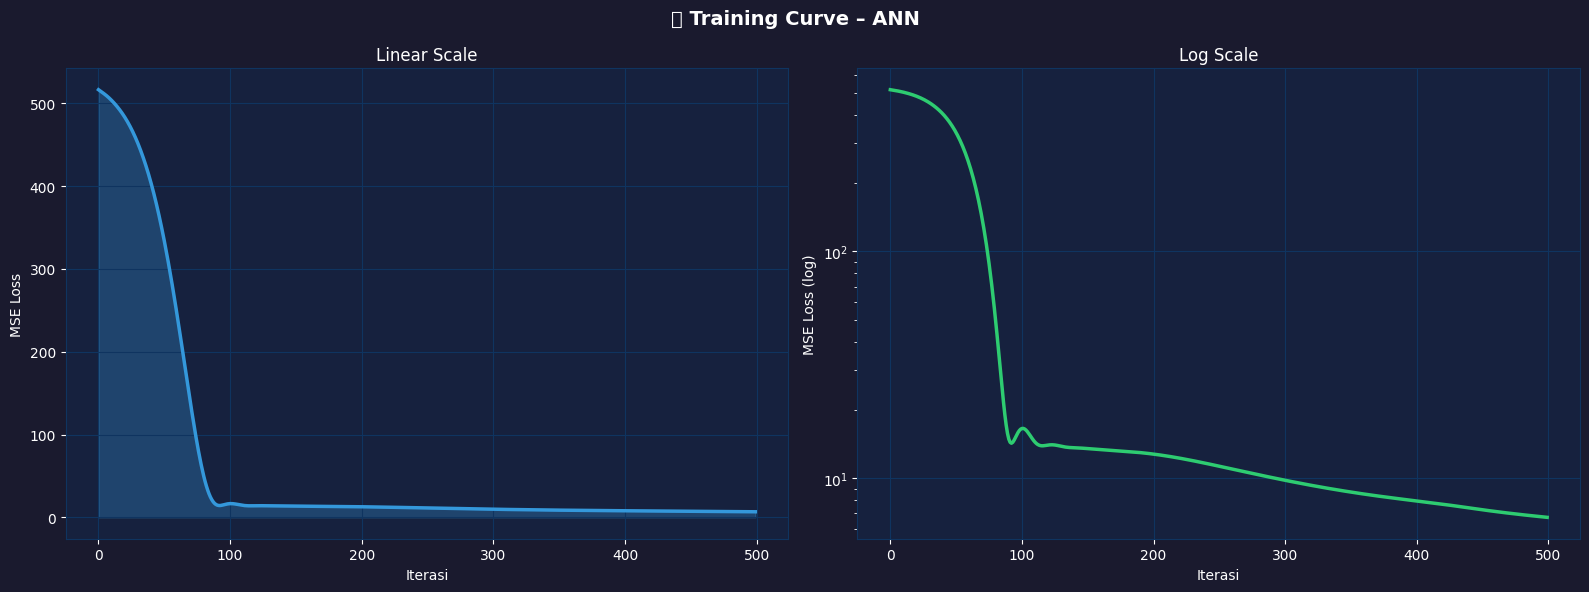

✅ Simpan → output/plots/training_curve.png


In [7]:
# Training curve terpisah
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📈 Training Curve – ANN', fontsize=14, fontweight='bold', color='white')
lc = ann.loss_curve_
axes[0].plot(lc, color='#3498DB', lw=2.5)
axes[0].fill_between(range(len(lc)), lc, alpha=0.3, color='#3498DB')
axes[0].set_title('Linear Scale'); axes[0].set_xlabel('Iterasi'); axes[0].set_ylabel('MSE Loss')
axes[1].semilogy(lc, color='#2ECC71', lw=2.5)
axes[1].set_title('Log Scale'); axes[1].set_xlabel('Iterasi'); axes[1].set_ylabel('MSE Loss (log)')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/training_curve.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/training_curve.png')

🔄 Menghitung feature importance...


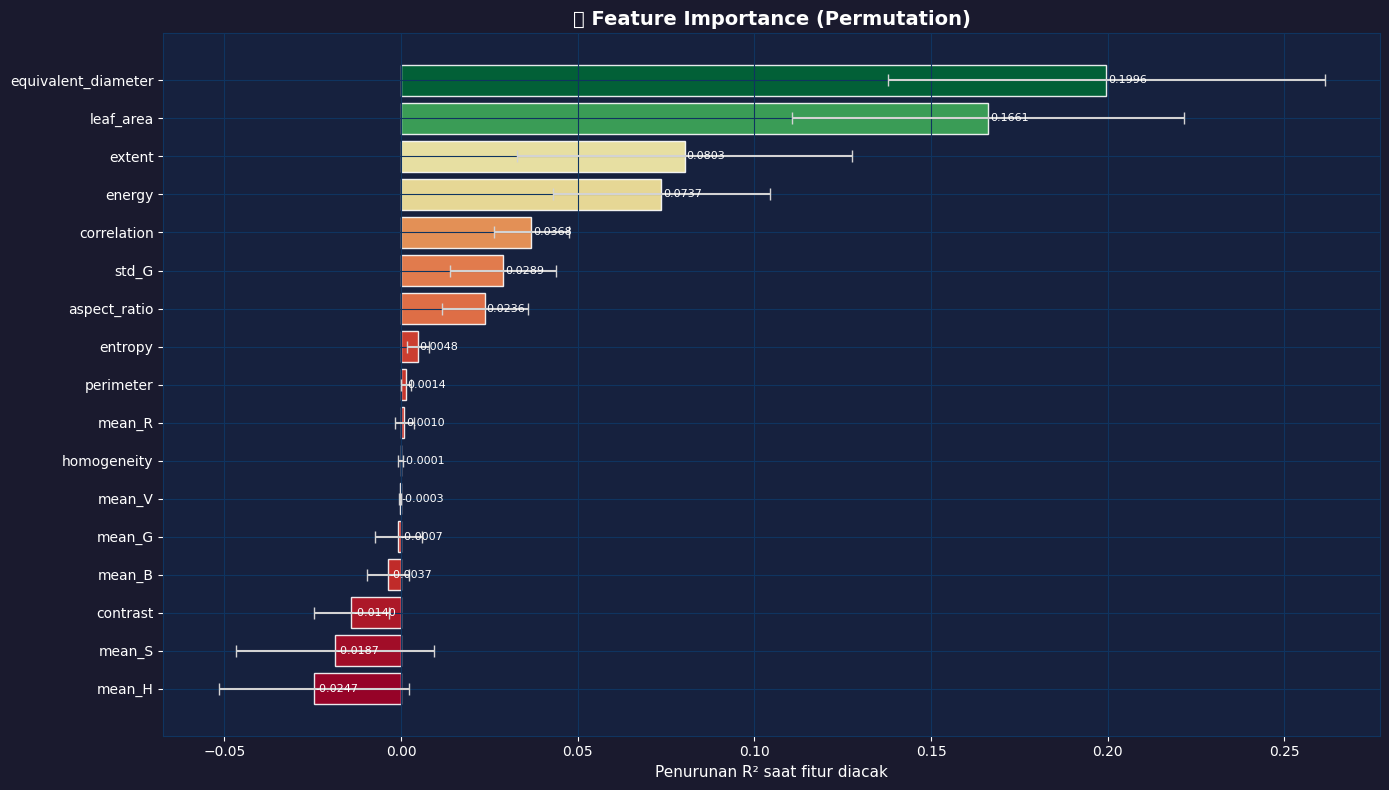

✅ Simpan → output/plots/feature_importance.png

📊 Top 5 Fitur:
  1. equivalent_diameter      : 0.1996 ± 0.0618
  2. leaf_area                : 0.1661 ± 0.0555
  3. extent                   : 0.0803 ± 0.0474
  4. energy                   : 0.0737 ± 0.0307
  5. correlation              : 0.0368 ± 0.0106


In [8]:
# Feature Importance via Permutation
print('🔄 Menghitung feature importance...')
pi = permutation_importance(ann, X_test_s, y_test, n_repeats=15, random_state=42, scoring='r2')

sidx    = np.argsort(pi.importances_mean)[::-1]
s_names = [FEATURE_COLUMNS[i] for i in sidx]
s_imp   = pi.importances_mean[sidx]
s_std   = pi.importances_std[sidx]
imp_norm = (s_imp - s_imp.min()) / (s_imp.max() - s_imp.min() + 1e-10)

fig, ax = plt.subplots(figsize=(14, 8))
colors  = plt.cm.RdYlGn(imp_norm)
ax.barh(s_names, s_imp, xerr=s_std, color=colors, alpha=0.9,
         edgecolor='white', capsize=4, ecolor='lightgray')
ax.invert_yaxis()
ax.set_title('🏆 Feature Importance (Permutation)', fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Penurunan R² saat fitur diacak', fontsize=11)

for y_pos, (val, std) in enumerate(zip(s_imp, s_std)):
    ax.text(val + 0.0005, y_pos, f'{val:.4f}', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/feature_importance.png')
print('\n📊 Top 5 Fitur:')
for i in range(min(5, len(s_names))):
    print(f'  {i+1}. {s_names[i]:25s}: {s_imp[i]:.4f} ± {s_std[i]:.4f}')

In [9]:
# Simpan model
joblib.dump(ann, f'{BASE_DIR}/output/models/ann_model.pkl')

print('=' * 55)
print('✅ NOTEBOOK 04 SELESAI!')
print('=' * 55)
print(f'  Model    → output/models/ann_model.pkl')
print(f'  Scaler   → output/models/scaler.pkl')
print()
print('📊 Performa (Test Set):')
print(f'  MAE  : {test_m["MAE"]:>10.4f} gram')
print(f'  RMSE : {test_m["RMSE"]:>10.4f} gram')
print(f'  R²   : {test_m["R2"]:>10.4f}')
print(f'  MAPE : {test_m["MAPE"]:>10.2f}%')
print()
print('📌 Lanjut → 05_PSO_Hyperparameter_Tuning.ipynb')

✅ NOTEBOOK 04 SELESAI!
  Model    → output/models/ann_model.pkl
  Scaler   → output/models/scaler.pkl

📊 Performa (Test Set):
  MAE  :     2.7901 gram
  RMSE :     3.6239 gram
  R²   :     0.6350
  MAPE :       8.88%

📌 Lanjut → 05_PSO_Hyperparameter_Tuning.ipynb
